# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

## 1. Setup

We solve the housing frictions model with **separable utility** $\mathrm{u}(c, H_{\succ}) = \alpha\,c^{1-\gamma_c}/(1{-}\gamma_c) + (1{-}\alpha)\,(\kappa\,H_{\succ})^{1-\gamma_h}/(1{-}\gamma_h)$ and compare two solution methods:
- **EGM(FUES)** inverts the Euler equations and recovers the upper envelope via FUES.
- **NEGM(FUES)** nests the keeper’s 1D EGM solution inside a golden-section search over the adjuster’s housing choice.

Both methods use FUES for the keeper’s upper envelope; they differ only in how the adjuster stage is solved.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
    nb_plot_value_functions,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve

In [2]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 1000, 'n_a': 1000, 'n_h': 1000, 
    },
    calib_overrides={
        't0': 20, 'tau': 0.07
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        _mo = {('adjuster_cons', 'cntn_to_dcsn_mover', 'upper_envelope'): method}
        nest, grids = solve(
            SYNTAX, method_overrides=_mo,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


Solving:   0%|          | 0/51 [00:00<?, ?it/s]

NEGM(FUES)


Solving:   0%|          | 0/51 [00:00<?, ?it/s]


  51 periods, ages 20–70
  r=0.045, R=1.045, r_H=0, R_H=1.0, beta=0.945, alpha=0.7, gamma_c=3.5, gamma_h=1.5, kappa=0.06, sigma=0.001, delta=0, tau=0.07, chi=0, theta=1.3498, K=1.3, lambdas=[4.329982, 0.610214, -0.0209832, 0.0003132, -1.72e-06, 0.0199949, 4.76e-05], tau_av=30
  n_a=1000, n_h=1000, n_w=1000, N_wage=4

  Method            Keeper    Adjuster      Tenure     Total
                (ms/period)  (ms/period)  (ms/period)     (sec)
  ────────────────────────────────────────────────────────────
  EGM(FUES)           1261          67        1843       189
  NEGM(FUES)          1042         106        1741       751


## 3. Adjuster policies

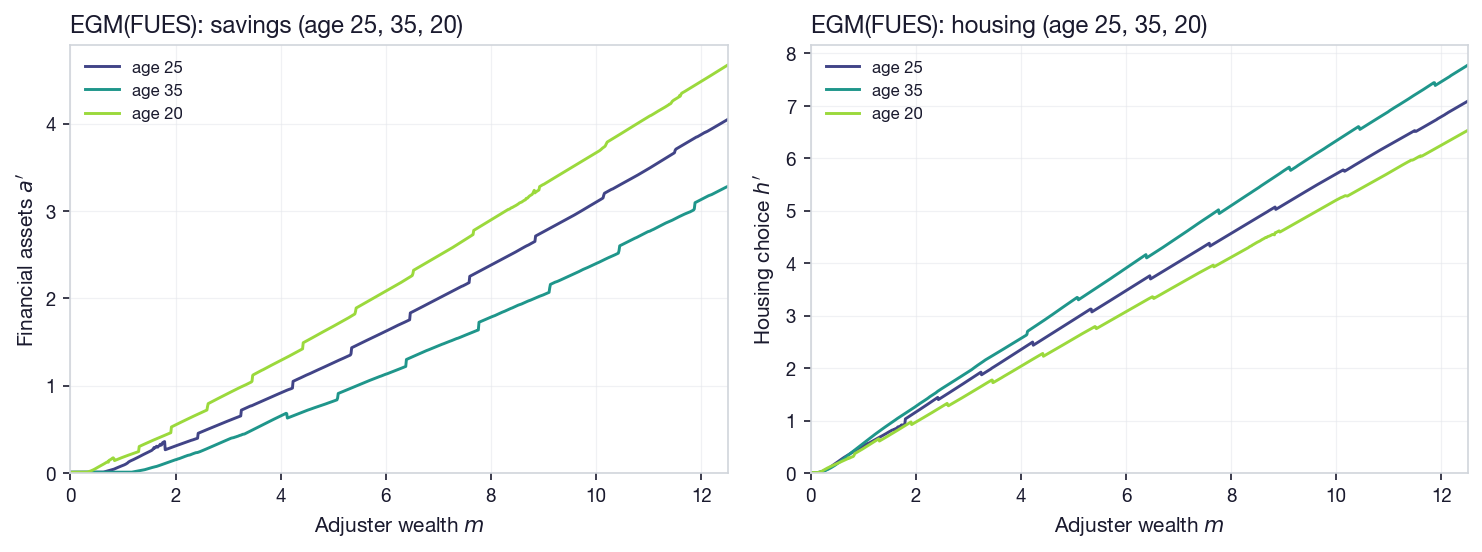

In [3]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[25, 35, 20], methods_filter=['FUES'], i_z=0, xlim=12.5)

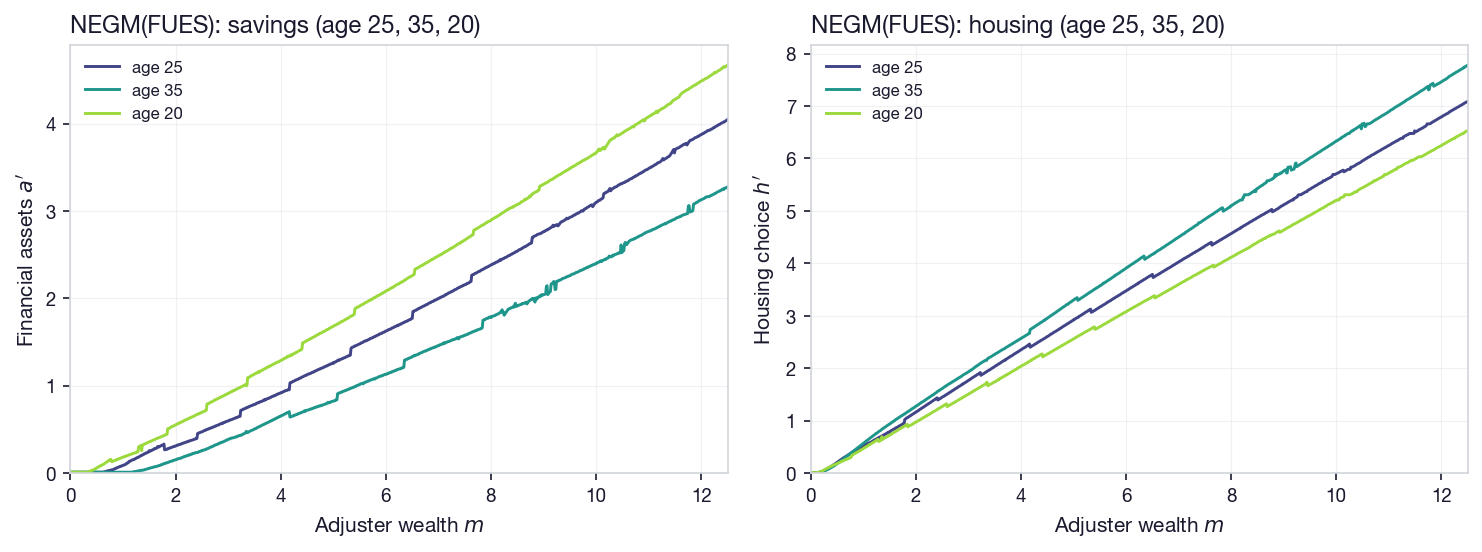

In [4]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[25, 35, 20], methods_filter=['NEGM'], i_z=0, xlim=12.5)

#fig = nb_plot_value_functions(
#    results, results['FUES']['grids'], plot_t=67)


## 4. Adjuster EGM grid

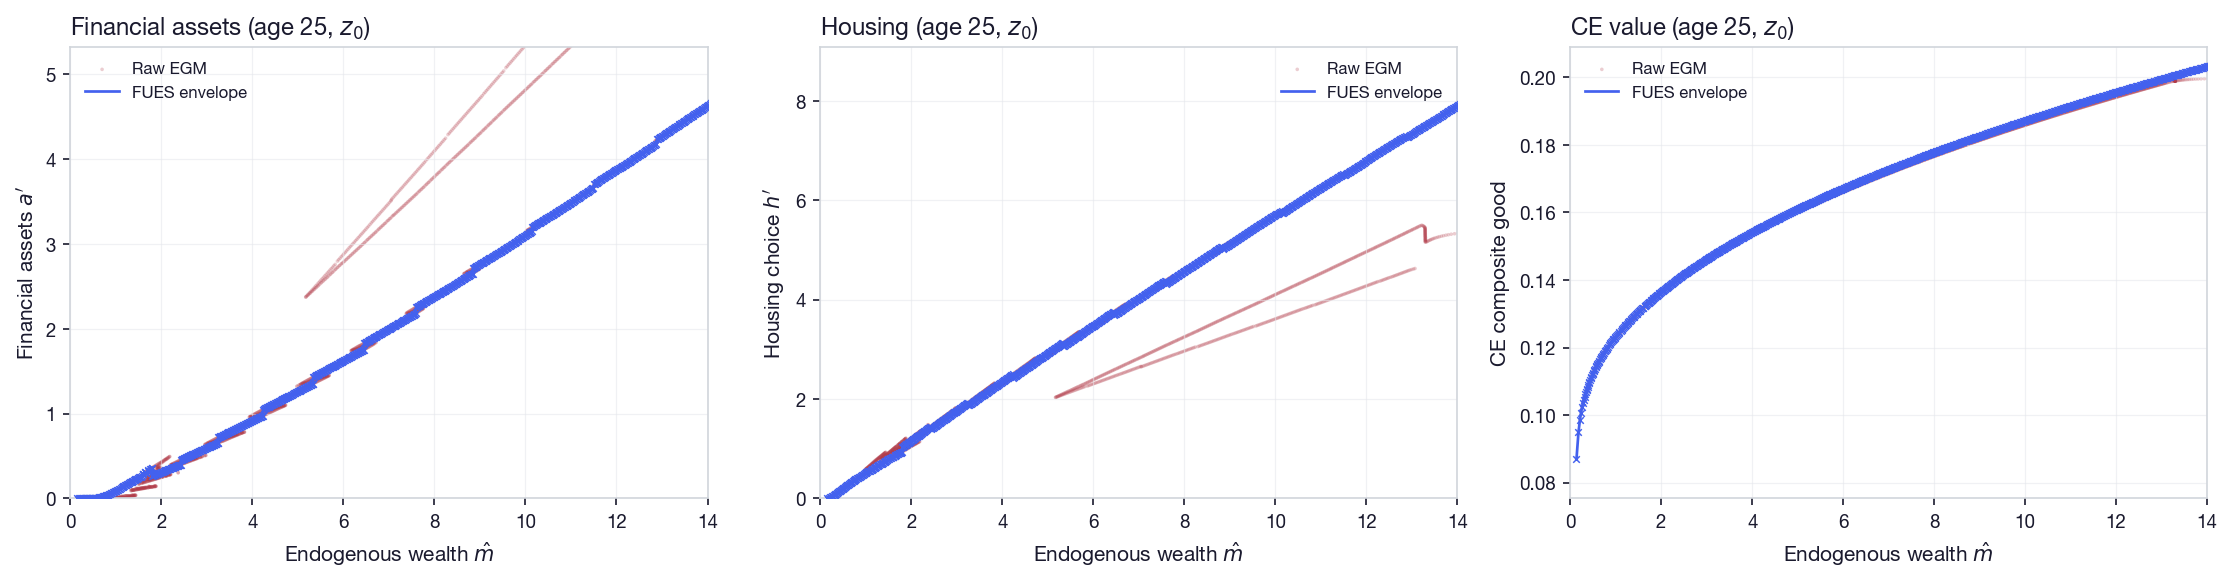

In [5]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=25, i_z=0)

In [6]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=25, i_z=0)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

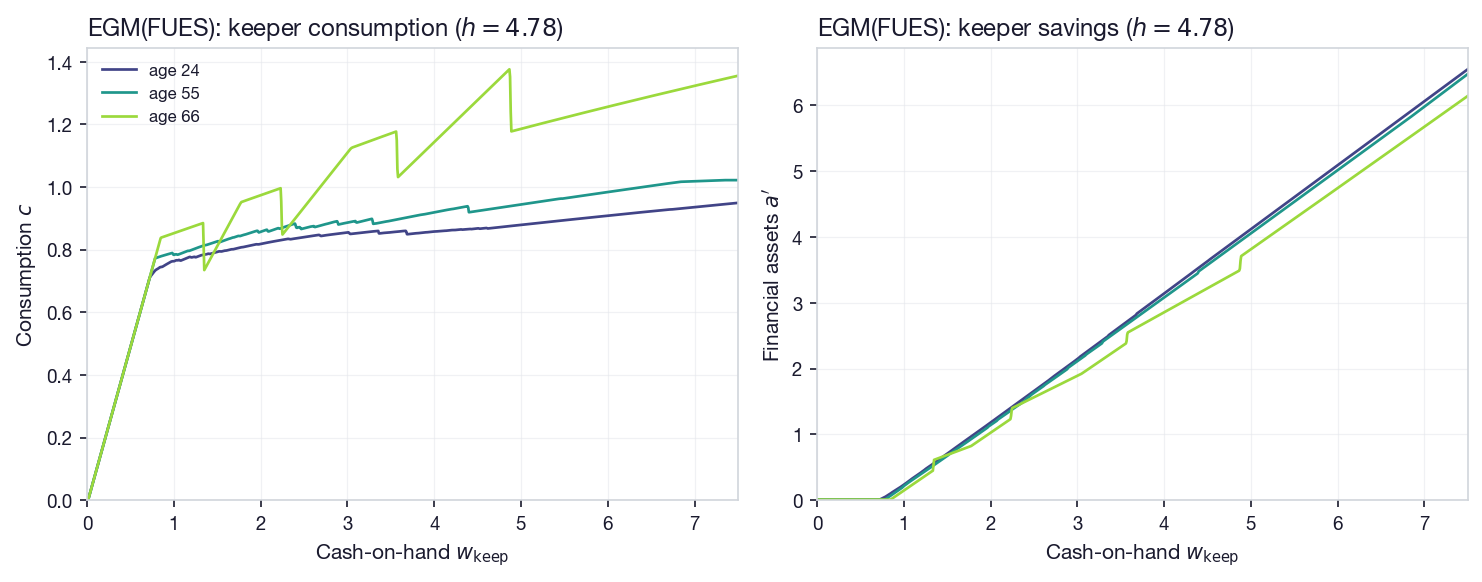

In [7]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['FUES'], i_z=3)

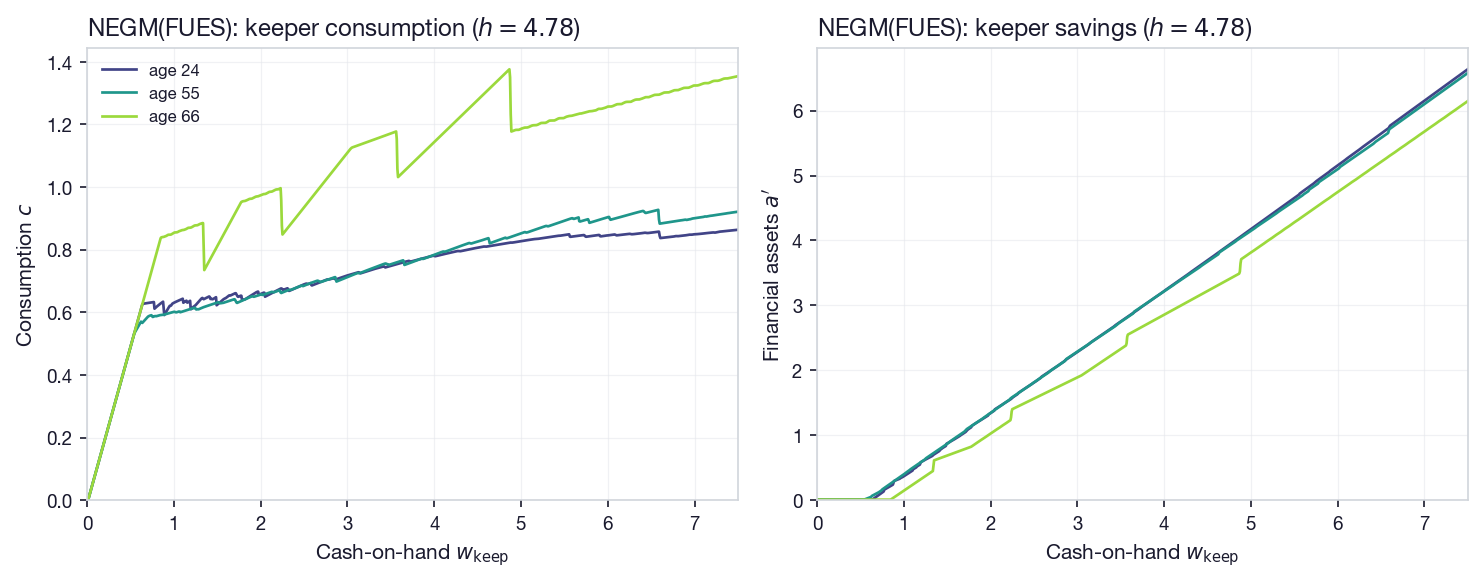

In [8]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['NEGM'])

## 6. Euler equation errors

In [9]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=21, init_dispersion=0.5)       
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


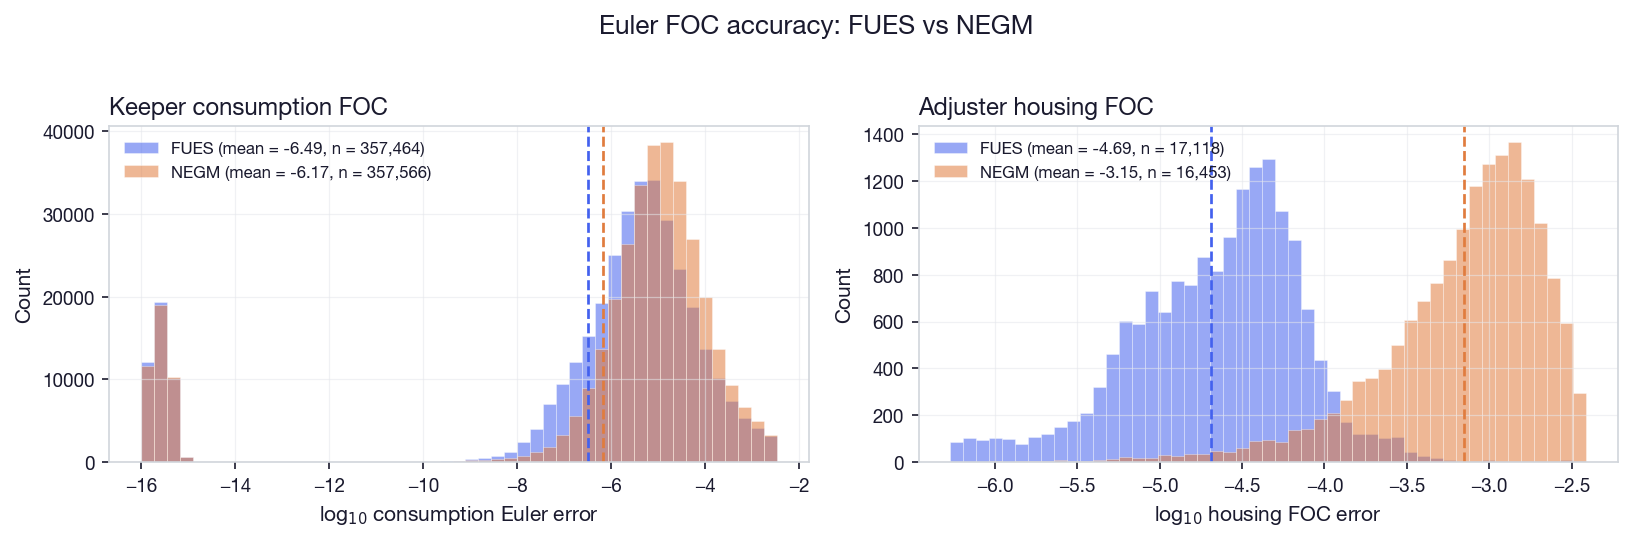

In [10]:
fig = plot_euler_histogram(euler_results)

### Welfare distribution

Per-agent certainty-equivalent utility, computed from the discounted NPV of flow utilities over the lifecycle.

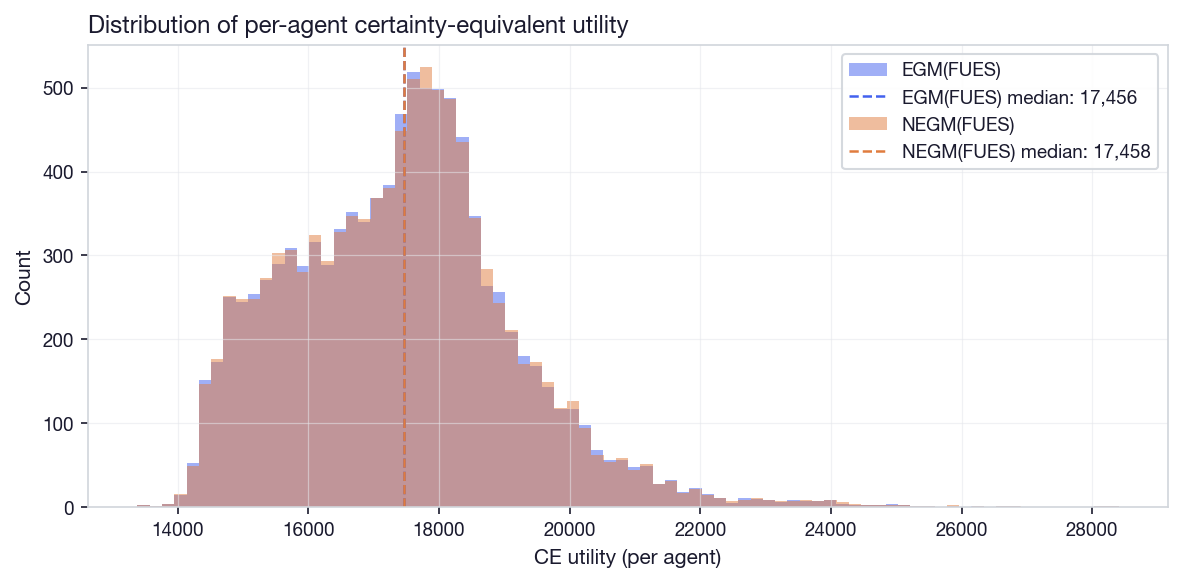

In [11]:
# ── Per-agent CE utility histogram ──
import matplotlib.pyplot as plt

_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data']['npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(ce, bins=80, alpha=0.5, label=_labels[method], color=_colors[method])
    ax.axvline(np.median(ce), color=_colors[method], ls='--', lw=1.2,
               label=f'{_labels[method]} median: {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Comparison of aggregates

In [12]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))




### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 1261 | 1042 |
| Adjuster (ms/period) | 67 | 106 |
| Total (ms/period) | 3172 | 2889 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -6.49 | -6.17 |
| Consumption: adjuster | -11.25 | -10.86 |
| Consumption: all | -6.71 | -6.38 |
| Housing: adjuster | -4.69 | -3.15 |
| **Simulation** |  |  |
| CE utility | 17,132.89 | 17,131.89 |
| Mean consumption ($) | 62,670 | 62,671 |
| Mean fin. assets ($) | 68,229 | 68,214 |
| Mean housing ($) | 247,602 | 247,634 |
| Adjustment rate (%) | 14.9 | 15.0 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


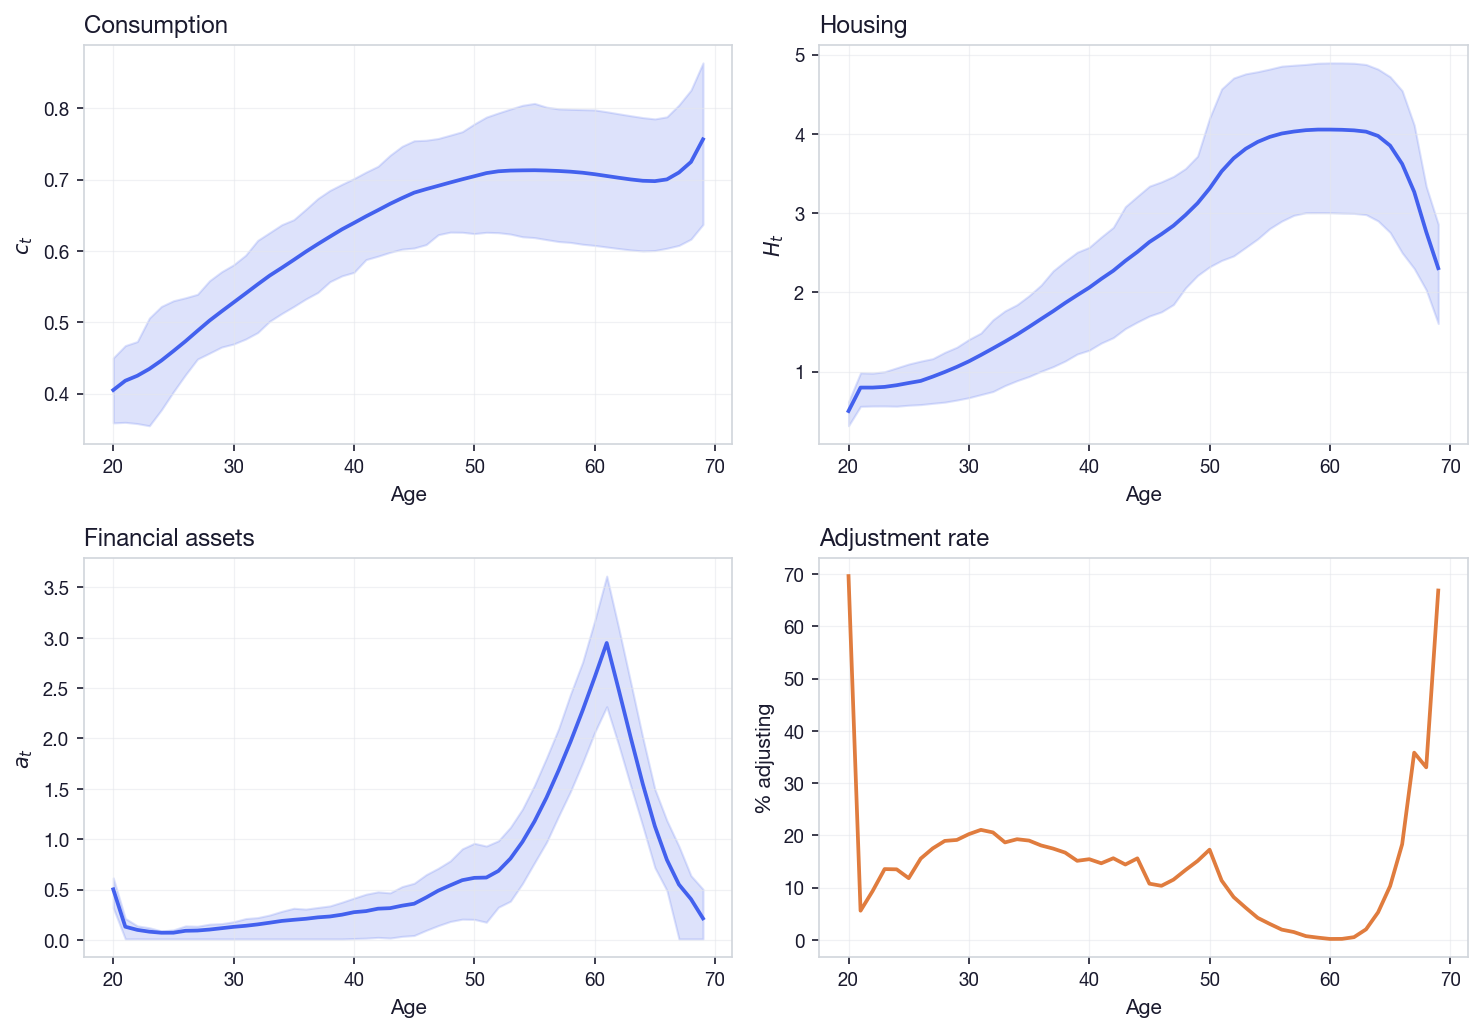

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


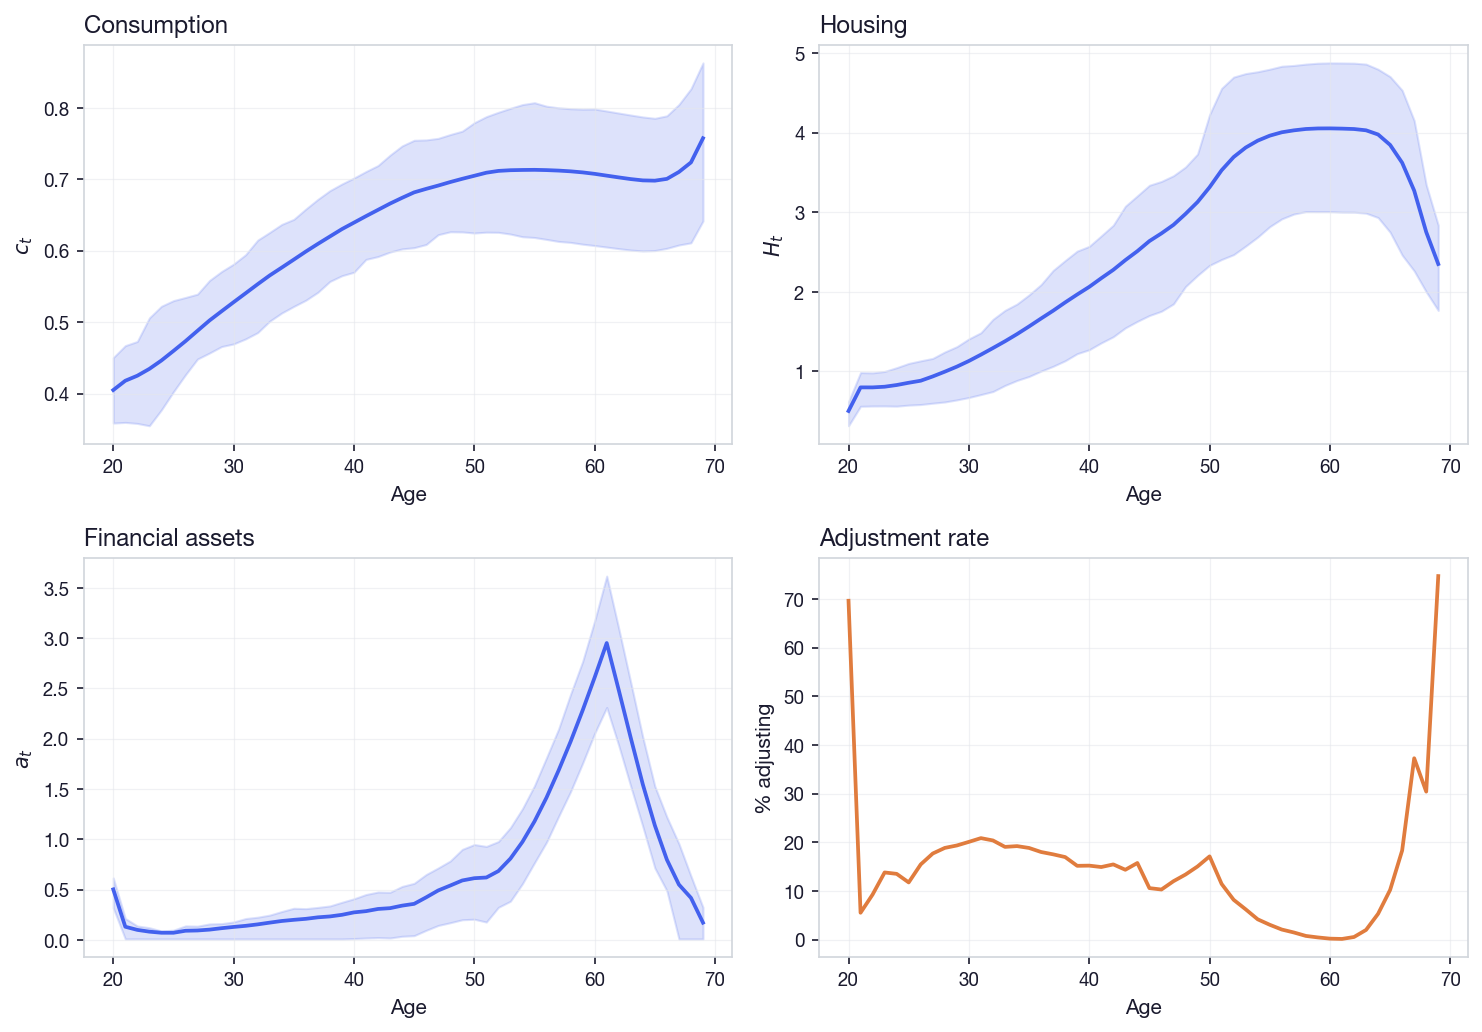

In [13]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [14]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | Mean c | SD c | Mean a | SD a | Mean H | SD H |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 20–24 | 42,572.82 | 7,851.66 | 17,751.50 | 22,759.24 | 74,727.34 | 34,505.13 |
| 25–29 | 48,770.70 | 8,736.43 | 9,527.06 | 13,128.98 | 94,641.12 | 45,517.65 |
| 30–34 | 55,264.80 | 8,848.01 | 15,700.81 | 19,595.41 | 129,600.35 | 64,266.26 |
| 35–39 | 60,931.66 | 9,087.65 | 22,362.44 | 25,838.26 | 176,458.83 | 82,819.96 |
| 40–44 | 65,710.84 | 9,370.31 | 30,562.40 | 33,325.92 | 228,245.76 | 100,521.60 |
| 45–49 | 69,133.47 | 9,850.95 | 48,129.25 | 44,801.87 | 286,285.63 | 118,804.95 |
| 50–54 | 71,035.74 | 11,051.20 | 74,065.39 | 55,882.25 | 364,833.73 | 139,000.26 |
| 55–59 | 71,188.11 | 12,422.28 | 170,444.40 | 78,125.82 | 401,954.65 | 141,451.05 |
| 60–64 | 70,287.89 | 12,679.14 | 231,843.60 | 95,224.59 | 403,060.61 | 141,413.57 |
| 65–69 | 71,799.24 | 13,820.21 | 61,902.05 | 54,850.80 | 316,213.32 | 133,005.28 |

**NEGM(FUES)**

| Age | Mean c | SD c | Mean a | SD a | Mean H | SD H |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 20–24 | 42,572.09 | 7,849.79 | 17,757.81 | 22,766.45 | 74,723.86 | 34,510.30 |
| 25–29 | 48,770.88 | 8,734.70 | 9,529.04 | 13,127.89 | 94,644.23 | 45,522.81 |
| 30–34 | 55,269.43 | 8,849.27 | 15,697.48 | 19,577.27 | 129,595.18 | 64,286.91 |
| 35–39 | 60,927.06 | 9,084.98 | 22,361.14 | 25,816.85 | 176,457.52 | 82,855.88 |
| 40–44 | 65,706.78 | 9,372.92 | 30,504.38 | 33,273.97 | 228,303.55 | 100,507.69 |
| 45–49 | 69,134.60 | 9,852.15 | 48,128.56 | 44,911.09 | 286,324.29 | 118,661.83 |
| 50–54 | 71,041.29 | 11,054.05 | 74,049.31 | 55,952.92 | 364,842.10 | 138,698.21 |
| 55–59 | 71,189.84 | 12,433.49 | 170,639.14 | 78,173.00 | 401,764.43 | 141,258.05 |
| 60–64 | 70,290.24 | 12,696.56 | 231,962.04 | 95,499.75 | 402,998.30 | 141,110.09 |
| 65–69 | 71,808.64 | 13,847.30 | 61,512.22 | 55,748.45 | 316,681.56 | 132,496.26 |